## <center>Test technique : Prédiction du vainqueur d'un match de tennis - Siwar ABBES</center> 
------------------------------------------------------------------------------------------------------------------


1. [Importation des librairies](#Importation)
2. [Exploration des données](#EDA)
3. [Feature Engineering](#engineering)
4. [Entrainement des modèles](#train)
5. [Prédiction et analyse des résultats](#predict)

#### Le but est de réaliser un modèle prédisant le vainqueur d’un match de tennis et d’en tirer de la valeur exploitable par un client.

Le livrable est un dossier contenant : 

- des scripts python exécutables et exécutés
- Un README.md présentant les instructions pour exécuter le code et les résultats dans les grandes lignes
- Un dossier avec des output (images et visualisations)
- Tout autre fichier qui permet d’exécuter le code et montrer les résultats

On souhaite avoir :

- Une exploration des données
- L'entra√Ænement de modèlesde prédiction
- Une analyse des performances
- Une présentation d'un cas d'utilisation
- Des pistes pour poursuivre le PoC
- Des script permettant la mise en production du code
chacune de ces parties fait l'objet d'une section dans le README.md

Conditions de passation :

A la maison
Cet exercice doit être réalisé en 4h maximum
Dans des conditions normales de travail (accès à internet, etc.)
Critères d'évaluation :

- Qualité de la méthode data science (la performance du modèle n’est pas le critère d’évaluation principal de l’exercice) ;
- Qualité de la compréhension du problème client, des données et des solutions envisagées
- Qualité de présentation des résultats
- Qualité du code: structuration, modularité, documentation
Important :

Merci de noter votre NOM Prénom sur le nom de fichier que vous nous transmettez.
Merci également de ne pas diffuser vos résultats publiquement (kaggle, github, gitlab, …). »

<a id='Importation'></a>
### 1. Importation des librairies

In [1]:
import warnings
from time import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set(rc={'figure.figsize':(8,6)})
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import json

import shap
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold, GridSearchCV, TimeSeriesSplit

<a id='EDA'></a>
### 2. Exploration des données

In [2]:
data = pd.read_csv("data/ATP_tweaked.csv", sep = ';')
print('The data shape is : ', data.shape)
print('\nThe data columns are : ', data.columns.values)

The data shape is :  (12310, 49)

The data columns are :  ['best_of' 'p2_1stIn' 'p2_1stWon' 'p2_2ndWon' 'p2_SvGms' 'p2_ace'
 'p2_bpFaced' 'p2_bpSaved' 'p2_df' 'p2_svpt' 'p2_age' 'p2_entry' 'p2_hand'
 'p2_ht' 'p2_id' 'p2_ioc' 'p2_name' 'p2_rank' 'p2_rank_points' 'p2_seed'
 'match_num' 'minutes' 'round' 'score' 'surface' 'tourney_date'
 'tourney_id' 'tourney_level' 'tourney_name' 'p1_1stIn' 'p1_1stWon'
 'p1_2ndWon' 'p1_SvGms' 'p1_ace' 'p1_bpFaced' 'p1_bpSaved' 'p1_df'
 'p1_svpt' 'p1_age' 'p1_entry' 'p1_hand' 'p1_ht' 'p1_id' 'p1_ioc'
 'p1_name' 'p1_rank' 'p1_rank_points' 'p1_seed' 'p1_won']


The data set contains the details about all the ATP matches played since 1968. The match
statistics are available for matches since 1991.


General
- tourneyid - tournamentid
- tourneyname - tournamentname
- surface - surface in which the match is played
- draw_size - the size of the draw
- tourney_level - tournament level
    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup
- tourney_date - starting date of the tournament
- match num - match number in a certain tournament
Players
- [prefixes : P1_ - info about player 1, P2_ - info about player 2]
- id - player id
- seed - the seed of the player in that tournament
- entry - How did the player enter the tournaments?
    - WC - Wildcard
    - Q - Qualifier
    - LL - Lucky loser
    - PR - Protected ranking
    - SE - Special Exempt
    - ALT - Alternate player
- name - player name
- hand - hand of the player, right or left
- ht - the height of the player
- IOC - the country of origin
- age - age of the player
- score - final score in the match
- best_of - the maximum number of sets played
- round - the round in the tournament a match belongs to
- minutes - duration of the match in minutes
- ace - number of aces in the match
- df - double faults
- svpt - serve percent
- 1stin - first serve in percent
- 1stWon - first serve winning percent
- 2ndWon - second serve winning percent
- SvGms - number of games played on serve (So, the maximum difference between
wSvGms and lSvGms will be 1)
- bpSaved - breakpoints save
- bpFaced - breakpoints faced
- p1_won : first player won

In [3]:
print('The data columns types are :\n \n', data.dtypes)

The data columns types are :
 
 best_of             int64
p2_1stIn          float64
p2_1stWon         float64
p2_2ndWon         float64
p2_SvGms          float64
p2_ace            float64
p2_bpFaced        float64
p2_bpSaved        float64
p2_df             float64
p2_svpt           float64
p2_age            float64
p2_entry           object
p2_hand            object
p2_ht             float64
p2_id               int64
p2_ioc             object
p2_name            object
p2_rank           float64
p2_rank_points    float64
p2_seed           float64
match_num           int64
minutes           float64
round              object
score              object
surface            object
tourney_date        int64
tourney_id         object
tourney_level      object
tourney_name       object
p1_1stIn          float64
p1_1stWon         float64
p1_2ndWon         float64
p1_SvGms          float64
p1_ace            float64
p1_bpFaced        float64
p1_bpSaved        float64
p1_df             float64
p1_svp

In [4]:
data.describe()

,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_bpSaved,p1_df,p1_svpt,p1_age,p1_ht,p1_id,p1_rank,p1_rank_points,p1_seed,p1_won
count,12310.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,...,11902.000000,11902.000000,11902.000000,12301.00000,9222.000000,12310.000000,12203.000000,12203.000000,4169.000000,12310.00000
mean,3.449553,49.557889,35.638800,16.104352,12.725004,6.597463,6.754243,4.117711,3.088052,81.201563,...,4.103428,3.107881,81.249202,27.77952,186.566580,107720.937043,97.749078,1464.070556,7.961861,0.50000
std,0.834904,19.340074,14.466661,7.167955,4.322233,5.767244,4.481091,3.250747,2.437863,29.776454,...,3.245153,2.461629,29.739695,4.42404,7.680804,11520.722732,173.310839,1906.471819,7.071728,0.50002
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,16.28000,163.000000,100644.000000,1.000000,1.000000,1.000000,0.00000
25%,3.000000,36.000000,25.000000,11.000000,10.000000,3.000000,3.000000,2.000000,1.000000,59.000000,...,2.000000,1.000000,59.000000,24.77000,183.000000,104607.000000,25.000000,581.500000,3.000000,0.00000
50%,3.000000,46.000000,33.000000,15.000000,12.000000,5.000000,6.000000,4.000000,3.000000,76.000000,...,4.000000,3.000000,76.000000,28.03000,185.000000,105223.000000,54.000000,877.000000,6.000000,0.50000
75%,3.000000,60.000000,43.000000,20.000000,15.000000,9.000000,9.000000,6.000000,4.000000,98.000000,...,6.000000,4.000000,98.000000,30.94000,190.000000,105967.000000,96.000000,1515.000000,10.000000,1.00000
max,5.000000,218.000000,171.000000,54.000000,50.000000,75.000000,30.000000,24.000000,21.000000,291.000000,...,25.000000,19.000000,278.000000,46.05000,208.000000,207972.000000,2147.000000,16790.000000,33.000000,1.00000


### Explorer la variable objective (the target)
Selon le jeu de données, nous pouvons évidemment conclure que la variable objective (Target object) à prédire est p1_won; si le premier joueur gagnerait la partie.

In [5]:
# Explore the target
print(" Le nombre de valeurs nulles pour la target:", data["p1_won"].isnull().sum())


print("\n Le nombre de victoires pour la target:", data["p1_won"].value_counts()[1])

print("\n Le pourcentage de victoires pour la target:", data["p1_won"].value_counts()[1] / data.shape[0] * 100, '%')

 Le nombre de valeurs nulles pour la target: 0

 Le nombre de victoires pour la target: 6155

 Le pourcentage de victoires pour la target: 50.0 %


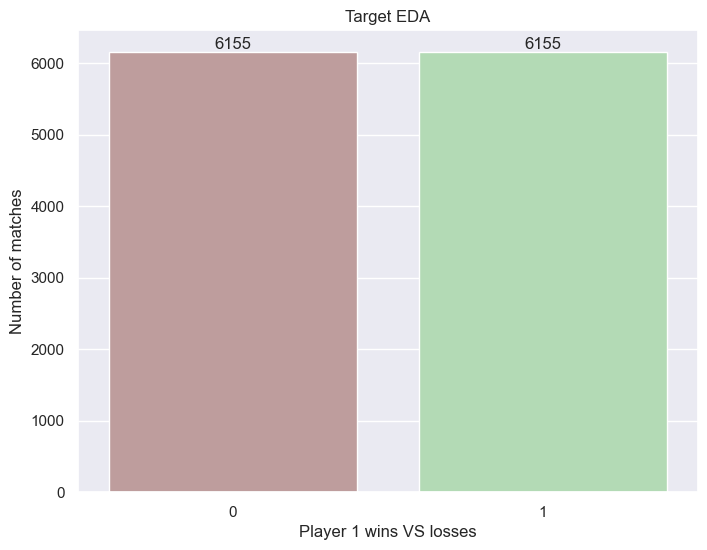

In [6]:
ax= sns.countplot(x='p1_won', data=data, palette=["#c39797", "#ace1af"])
ax.bar_label(ax.containers[0])
ax.set_title('Target EDA')
ax.set_xlabel('Player 1 wins VS losses')
ax.set_ylabel('Number of matches')
plt.show()

Conclusion : 
On est face à un problème supervisé de <b> classification binaire avec des classes équilibrées. </b> <br>
Les métriques qu'il faudrait donc utiliser pour juger la performance du modèle sont :

- Accuracy
- Precision
- Recall
- F1-score : une mesure qui permet de donner une valeur équilibrée entre la précision et le recall



### Missing values

In [7]:
def display_na(all_data):
    all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
    all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
    f, ax = plt.subplots(figsize=(8, 6))
    plt.xticks(rotation='90')
    sns.barplot(x=all_data_na.index, y=all_data_na)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Percent of missing values', fontsize=15)
    plt.title('Percent missing data by feature', fontsize=15)

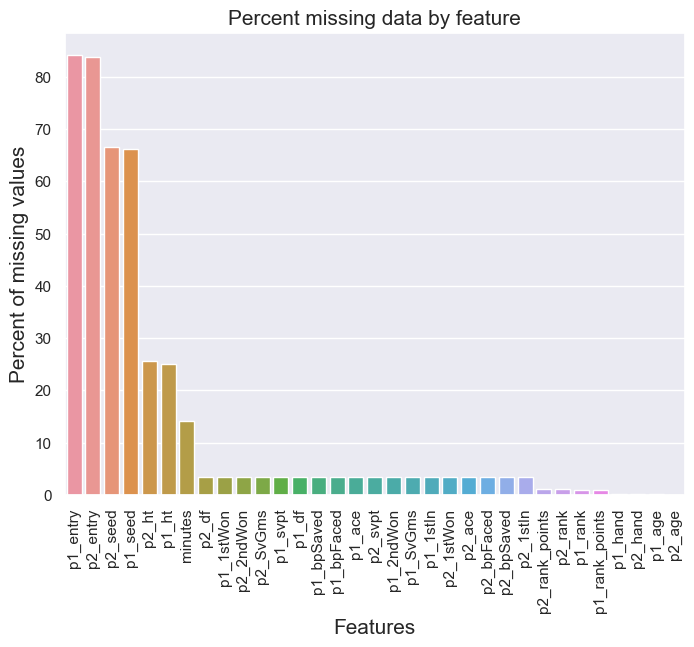

In [8]:
display_na(data)

###  Variables catégoriques

In [9]:
features = {c: data[c].nunique() for c in data.columns}
features_with_nb_categories ={k:v for k, v in sorted(features.items(), key=lambda item: item[1])} 
features_with_nb_categories

{'best_of': 2,
 'p1_won': 2,
 'p2_hand': 3,
 'p1_hand': 3,
 'surface': 5,
 'tourney_level': 5,
 'p1_entry': 6,
 'p2_entry': 7,
 'round': 9,
 'p2_ht': 19,
 'p1_ht': 19,
 'p1_df': 20,
 'p2_df': 21,
 'p1_bpSaved': 24,
 'p2_bpSaved': 25,
 'p1_bpFaced': 30,
 'p2_bpFaced': 31,
 'p2_seed': 33,
 'p1_seed': 33,
 'p2_SvGms': 40,
 'p1_SvGms': 40,
 'p2_ace': 51,
 'p1_ace': 52,
 'p2_2ndWon': 54,
 'p1_2ndWon': 54,
 'p1_ioc': 86,
 'p2_ioc': 88,
 'p2_1stWon': 110,
 'p1_1stWon': 114,
 'p2_1stIn': 142,
 'p1_1stIn': 146,
 'tourney_date': 179,
 'p1_svpt': 211,
 'p2_svpt': 213,
 'minutes': 284,
 'match_num': 343,
 'tourney_name': 374,
 'tourney_id': 579,
 'p1_id': 628,
 'p1_name': 628,
 'p2_id': 657,
 'p2_name': 657,
 'p2_rank': 683,
 'p1_rank': 716,
 'p1_age': 1914,
 'p2_age': 1928,
 'p2_rank_points': 1964,
 'p1_rank_points': 1987,
 'score': 3729}

- **Les variables catégoriques** prennent en effet des valeurs dans un ensemble finit de valeur, la question qui reste à savoir est le cardinal de cette ensemble. **Nous supposerons que la valeur limite à partir de laquelle nous considérerons la variable comme non catégorique est 10** :
        - Best_of : [3, 5]
        - pi_hand : ['L', 'R', 'U']   # U: Unkonwn
        - surface : ['Hard', 'Grass', 'Clay', 'None', 'Carpet'] # None
        - tourney_level : ['M', 'A', 'G', 'D', 'F']  # A : other tour-level events
        - pi_entry : ['Q', 'SE', 'LL', 'WC', 'PR', 'ALT', 'S']  
        - round : ['R64', 'R32', 'R16', 'QF', 'R128', 'SF', 'F', 'RR', 'BR']
        - p1_ioc : The country of origin ['FRA', 'GER', 'SUI', 'URU', 'CAN', 'USA' ...] (88 countries)
        - pi_name/pi_id : 675 players

**Winner name**

In [10]:
df_eda = data.copy()
df_eda['winner_name'] = np.where(df_eda['p1_won'] == 1, df_eda['p1_name'], df_eda['p2_name'])
df_eda[[ 'p1_name', 'p2_name', 'p1_won', 'winner_name']].head()

,p1_name,p2_name,p1_won,winner_name
0,Jo Wilfried Tsonga,Fernando Verdasco,0,Fernando Verdasco
1,Jan Lennard Struff,Marcos Baghdatis,1,Jan Lennard Struff
2,Stanislas Wawrinka,Donald Young,1,Stanislas Wawrinka
3,Pablo Cuevas,Rafael Nadal,0,Rafael Nadal
4,Frank Dancevic,Igor Sijsling,0,Igor Sijsling


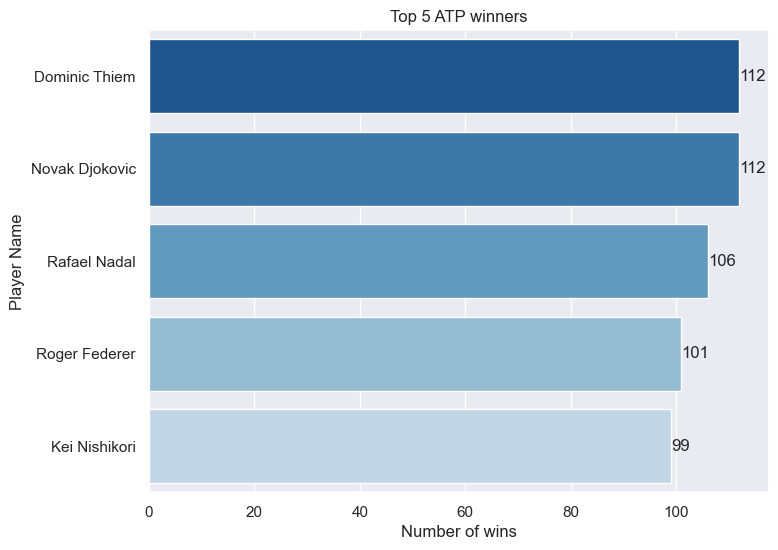

In [11]:
order = df_eda.groupby('winner_name').agg({'p1_won':'sum'})
order = order.apply(lambda x: x.sort_values(ascending=False)[:5])
order = order.reset_index()
# The three (3) ATP players with most wins
palette = sns.color_palette("Blues_r")
ax = sns.barplot(x="p1_won", y="winner_name", data=order, palette=np.array(palette)[order.index])
ax.bar_label(ax.containers[0])
ax.set_title('Top 5 ATP winners')
ax.set_ylabel('Player Name')
ax.set_xlabel('Number of wins')
plt.show()

### Date

La variable **tourney_date** est indiquée sous forme numérique alors que ce n'est pas le format adéquat pour représenter une date et qui nécessite donc un prétraitement.

In [12]:
data.tourney_date.min(), data.tourney_date.max() 

(20150104, 20190225)

In [13]:
pd.to_datetime(data['tourney_date'],format="%Y%m%d").min()

Timestamp('2015-01-04 00:00:00')

--------------------------------------------------------------------------------------------

### 2.2 Variables catégoriques

#### player hand


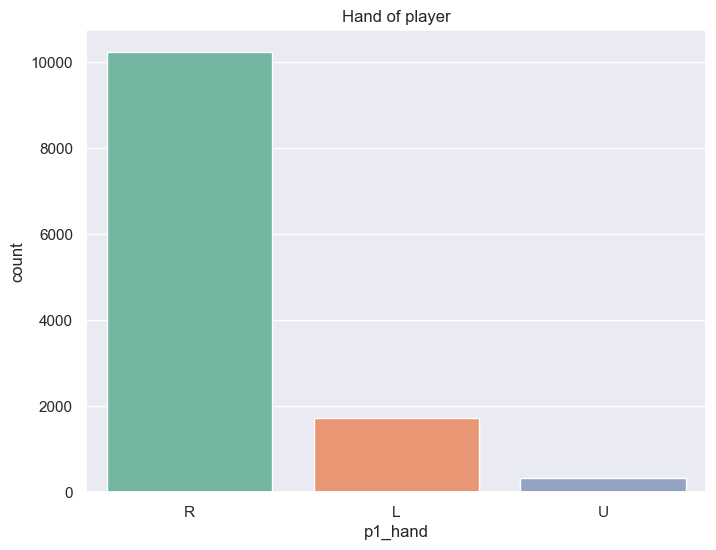

In [14]:
ax = sns.countplot(x='p1_hand', data=data, palette=sns.color_palette("Set2"))
ax.set_title("Hand of player")
plt.show()

As we can notice here, most of players use their right hand which is evident, and as we already have an extra class "U", we will use it to impute missing values

#### Tournament level


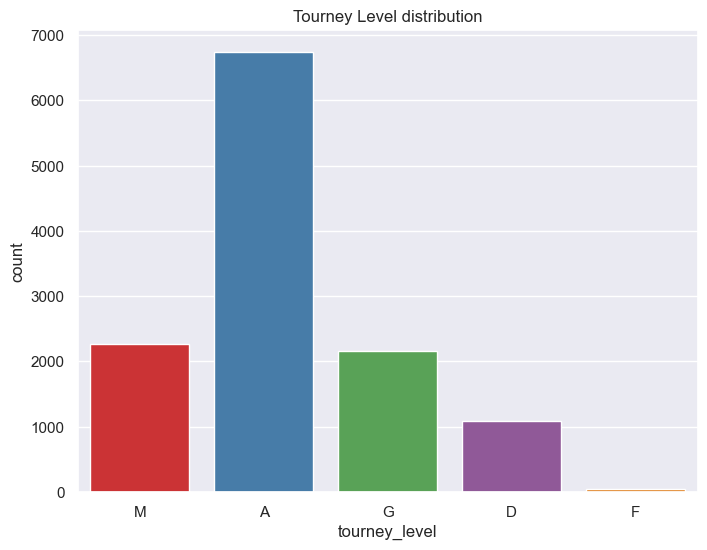

In [15]:
ax = sns.countplot(x='tourney_level', data=data, palette=sns.color_palette("Set1"))
ax.set_title("Tourney Level distribution")
plt.show()

    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup

As we can notice here, there are not data for S and C tournement level in our data

#### Surface Type

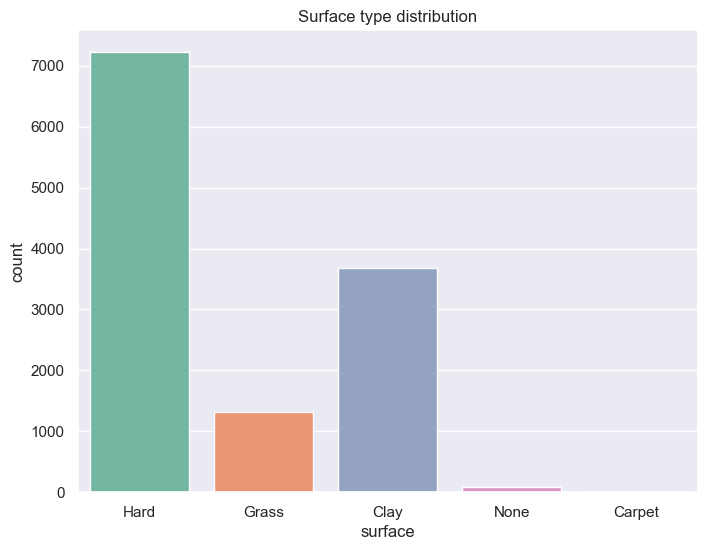

In [16]:
ax = sns.countplot(x="surface", data=data, palette=sns.color_palette("Set2"))
ax.set_title("Surface type distribution")
plt.show()

#### Height

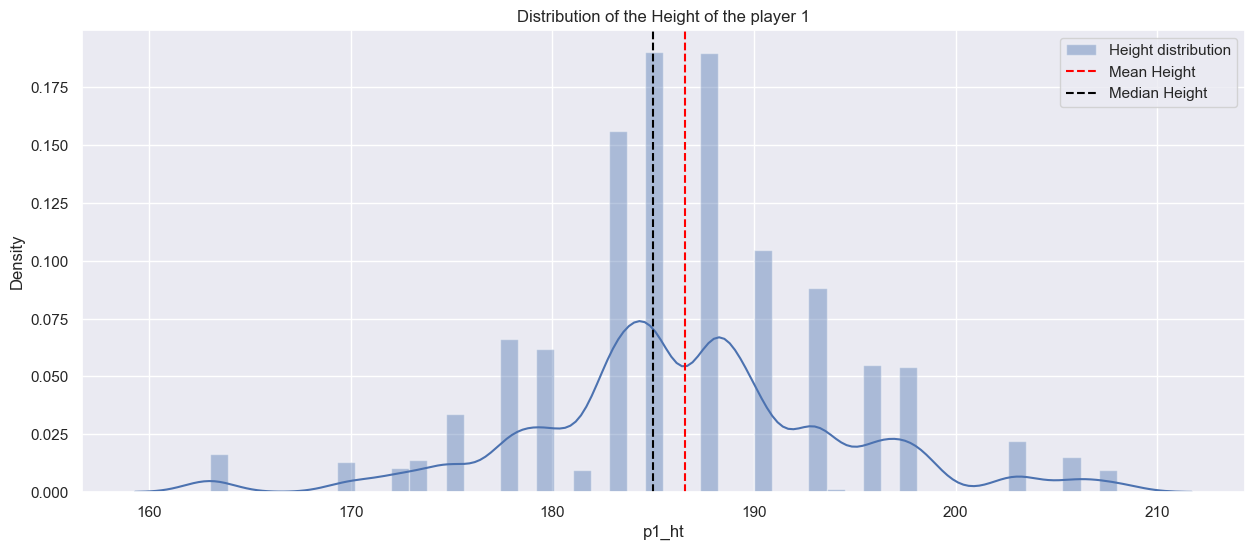

In [17]:
plt.figure(figsize=(15,6))
sns.distplot(data['p1_ht'], label='Height distribution')
plt.axvline(x=data['p1_ht'].mean(), color='red', linestyle='--', label='Mean Height')
plt.axvline(x=data['p1_ht'].median(), color='black', linestyle='--', label='Median Height')
plt.title('Distribution of the Height of the player 1')
plt.legend()
plt.show()

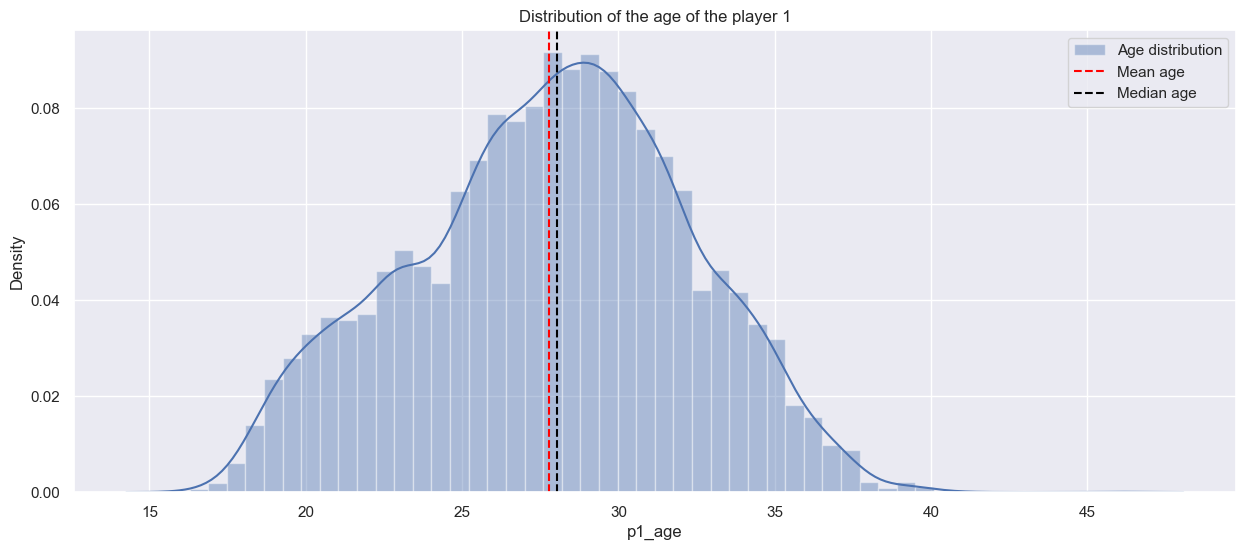

In [18]:
#### age

plt.figure(figsize=(15,6))
sns.distplot(data['p1_age'], label='Age distribution')
plt.axvline(x=data['p1_age'].mean(), color='red', linestyle='--', label='Mean age')
plt.axvline(x=data['p1_age'].median(), color='black', linestyle='--', label='Median age')
plt.title('Distribution of the age of the player 1')
plt.legend()
plt.show()

--------------------------------------------------------------------------------------------------------------
<a id = 'preprocessing'></a>
## 3. Preprocessing


As first step, let's clean the data and retain only important features for our prediction task.

We proceed to the removal of features that are redundant/ crrelated with each other, and those that are obviously not available before a match to predict.

We will drop "p1_name" and "p2_name" because they are almost redundant and replaceable by respectively "p1_id", "p2_id"


"minutes", "score", "1stIn", "_1stWon", "_2ndWon", "SvGms", "l_bpFaced", "l_bpSaved", "svpt", "ace", "df" features because cannot be known in advance.

In [19]:
preprocessed_data = data.copy()

In [20]:
params = {
'features_to_drop': ['tourney_name', 'tourney_id', 'p2_name', 'p1_name', 'minutes', 'score',
                     'p1_1stIn', 'p2_1stIn', 'p1_1stWon', 'p2_1stWon', 'p1_2ndWon', 'p2_2ndWon',
                     'p1_SvGms', 'p2_SvGms', 'p1_svpt','p2_svpt', 'p1_bpFaced', 'p2_bpFaced', 'p1_bpSaved', 
                     'p2_bpSaved','p1_ace','p2_ace','p1_df', 'p2_df']
}

print(f'Features to drop: {params["features_to_drop"]}')
preprocessed_data = preprocessed_data.drop(columns=params['features_to_drop'], axis=1)

Features to drop: ['tourney_name', 'tourney_id', 'p2_name', 'p1_name', 'minutes', 'score', 'p1_1stIn', 'p2_1stIn', 'p1_1stWon', 'p2_1stWon', 'p1_2ndWon', 'p2_2ndWon', 'p1_SvGms', 'p2_SvGms', 'p1_svpt', 'p2_svpt', 'p1_bpFaced', 'p2_bpFaced', 'p1_bpSaved', 'p2_bpSaved', 'p1_ace', 'p2_ace', 'p1_df', 'p2_df']


In [21]:
def get_columns_with_nan_values(data) -> dict[str, str]:
        """
        Find columns that contain nan values.
        """
        nb_rows = len(data)
        features_with_nan_values: dict[str, float] = {
            c: round((1 - data[c].count() / nb_rows) * 100, 2)
            for c in data.columns
            if data[c].count() < nb_rows
        }
        return {
            k: f'{str(v)}%'
            for k, v in sorted(
                features_with_nan_values.items(),
                key=lambda item: item[1],
                reverse=True,
            )
        }
features_with_nan_values = get_columns_with_nan_values(preprocessed_data)
print(f'\nFeatures with missing values : {json.dumps(features_with_nan_values, indent = 4)}')


Features with missing values : {
    "p1_entry": "84.22%",
    "p2_entry": "83.7%",
    "p2_seed": "66.5%",
    "p1_seed": "66.13%",
    "p2_ht": "25.53%",
    "p1_ht": "25.09%",
    "p2_rank": "1.14%",
    "p2_rank_points": "1.14%",
    "p1_rank": "0.87%",
    "p1_rank_points": "0.87%",
    "p2_hand": "0.19%",
    "p1_hand": "0.19%",
    "p1_age": "0.07%",
    "p2_age": "0.04%"
}


We can see that we have a lot of null values, so we have to handle them.

We will remove feature that have more than 80% of None values.

In [22]:
params["features_to_drop"].extend(['p1_entry', 'p2_entry'])
preprocessed_data = preprocessed_data.drop(columns=['p1_entry', 'p2_entry'], axis=1)

Since "rank_points" and "rank", which contain past performance of players, and "surface" features are important ones, we will delete the entries that do not contain information about them.

In [23]:
# To avoid analytical errors, we will convert numerical values of string format to float type.
numeric_columns = ['p1_rank', 'p2_rank', 'p1_age', 'p2_age', 'p1_ht', 'p2_ht']
preprocessed_data[numeric_columns] = preprocessed_data[numeric_columns].astype(float)
preprocessed_data.head()

,best_of,p2_age,p2_hand,p2_ht,p2_id,p2_ioc,p2_rank,p2_rank_points,p2_seed,match_num,...,tourney_level,p1_age,p1_hand,p1_ht,p1_id,p1_ioc,p1_rank,p1_rank_points,p1_seed,p1_won
0,3,31.75,L,188.0,104269,ESP,43.0,995.0,NaN,2,...,M,30.33,R,188.0,104542,FRA,19.0,1645.0,NaN,0
1,3,30.97,R,183.0,104571,CYP,41.0,1060.0,NaN,275,...,A,26.12,R,NaN,105526,GER,89.0,650.0,NaN,1
2,5,26.11,L,183.0,105385,USA,68.0,730.0,NaN,117,...,G,30.43,R,183.0,104527,SUI,5.0,5710.0,5.0,1
3,3,28.71,L,185.0,104745,ESP,3.0,5745.0,1.0,25,...,A,29.13,R,180.0,104655,URU,23.0,1447.0,6.0,0
4,3,27.46,R,190.0,104997,NED,100.0,556.0,NaN,12,...,A,30.35,R,185.0,104433,CAN,156.0,326.0,NaN,0


In [24]:
class PreProcessing:
    """Deal with nan values, drop useless columns"""
    
    def __init__(self, data: pd.DataFrame, features_to_drop:list[str], features_to_fill_by_median:list[str],\
                features_to_remove_nan_values:list[str]) -> None:
        self.data = data.copy()
        self.features_to_drop = features_to_drop
        self.features_to_fill_by_median = features_to_fill_by_median
        self.features_to_remove_nan_values = features_to_remove_nan_values


    def preprocess(self) -> pd.DataFrame:
        """ Drop dupclicated, Apply missing values imputation """
        # drop duplicates
        self.data.drop_duplicates(inplace=True)
        # fill nan values
        self._fill_nan_values()
        self._split_date()
        return self.data
                 
 
    def _fill_nan_values(self) -> None:
        """
        Fill nan values
        """
        print(f'\nFeatures to fill missing values with median : {self.features_to_fill_by_median}')
        print(f'\nFeatures to remove empty rows : {self.features_to_remove_nan_values}')
         
        # fill nan values by a median
        for c in self.features_to_fill_by_median:
            self.data[c] = self.data[c].fillna((self.data[c].median()))
        
        ## fillna for pi_hand with 'U' as there is already an unkonwn category
        self.data['p1_hand'] = self.data['p1_hand'].fillna('U')
        self.data['p2_hand'] = self.data['p2_hand'].fillna('U')
        self.data.reset_index(inplace=True, drop=True)
        

        features_with_nan_values = get_columns_with_nan_values(self.data)
        print(f'\nFeatures with missing values after pre-processing: {features_with_nan_values}')
        # remove empty rows for important features
        self.data.replace(to_replace=['None'], value=None, inplace=True)
        self.data.dropna(how='any',inplace=True)     
            
        return None
    
    def _split_date(self) -> None:
        """  Extract the year, the month and the day from the column tourney date.
        """
        self.data['tourney_date'] = pd.to_datetime(self.data['tourney_date'], format="%Y%m%d")
        self.data["day"] = self.data["tourney_date"].map(lambda x: x.day)
        self.data["month"] = self.data["tourney_date"].map(lambda x: x.month)
        self.data["year"] = self.data["tourney_date"].map(lambda x: x.year)
        self.data['is_weekend'] = self.data["tourney_date"].map(lambda x : 1 if x.weekday() >= 5 else 0 )
        return

In [25]:
params.update({
'features_to_remove_nan_values': ['p1_rank_points', 'p2_rank_points', 'p1_rank', 'p2_rank', 'surface'],
'features_to_fill_by_median': [ 'p1_rank','p2_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 
                                'p2_rank_points', 'p2_age', 'p2_ht',  'p1_seed', 'p2_seed']

})

In [26]:
# Preprocess data
## Let's now count the number and the percentage of None values in our data set 
## drop redundant and features that are not known before the match
preprocessing = PreProcessing(preprocessed_data, params['features_to_drop'],  \
    params['features_to_fill_by_median'], params['features_to_remove_nan_values'])
preprocessing.preprocess()
print(f'\nData shape after cleaning and preprocessing : {preprocessing.data.shape}')
preprocessed_data = preprocessing.data
print(f"\nremained features : {list(preprocessed_data.columns)}")


Features to fill missing values with median : ['p1_rank', 'p2_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 'p2_rank_points', 'p2_age', 'p2_ht', 'p1_seed', 'p2_seed']

Features to remove empty rows : ['p1_rank_points', 'p2_rank_points', 'p1_rank', 'p2_rank', 'surface']

Features with missing values after pre-processing: {}

Data shape after cleaning and preprocessing : (12230, 27)

remained features : ['best_of', 'p2_age', 'p2_hand', 'p2_ht', 'p2_id', 'p2_ioc', 'p2_rank', 'p2_rank_points', 'p2_seed', 'match_num', 'round', 'surface', 'tourney_date', 'tourney_level', 'p1_age', 'p1_hand', 'p1_ht', 'p1_id', 'p1_ioc', 'p1_rank', 'p1_rank_points', 'p1_seed', 'p1_won', 'day', 'month', 'year', 'is_weekend']


In [27]:
preprocessed_data.surface.unique()

array(['Hard', 'Grass', 'Clay', 'Carpet'], dtype=object)

--------------------------------------------------------------------------------------------------------------
<a id = 'engineering'></a>
### 3. Feature Engineering

In [28]:
def train_test_split_per_time(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series,pd.Series]:
    """Apply feature engineering and split data for training and test

    Args:
        data (pd.DataFrame): preprocessed data
    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.Series,pd.Series]: X_train, X_test, y_train, y_test
    """

    print(f'''\n{'-'*20} Feature Engineering  {'-'*20}''')
    print(f'\nSplit Data into train and test data :')
    data['tourney_date'] = pd.to_datetime(data['tourney_date'], format="%Y%m%d")
    train_df = data[data['tourney_date'] < '2018-05-01']
    test_df = data[data['tourney_date'] >= '2018-05-01']
    
    print(f'Data Train shape : {train_df.shape}, from {min(train_df["tourney_date"])} to {max(train_df["tourney_date"])}')
    print(f'Data Test shape : {test_df.shape}, from {min(test_df["tourney_date"])} to {max(test_df["tourney_date"])}')

    
    X_train = train_df.drop(columns=['p1_won', 'tourney_date'])
    X_test = test_df.drop(columns=['p1_won', 'tourney_date'])
    y_train = train_df["p1_won"]
    y_test = test_df["p1_won"]
    
    # reset_index
    X_train.reset_index(inplace=True, drop=True)
    y_train.reset_index(inplace=True, drop=True)
    X_test.reset_index(inplace=True, drop=True)
    y_test.reset_index(inplace=True, drop=True)

    return X_train, X_test, y_train, y_test


In [29]:
# Feature engineering
X_train, X_test, y_train, y_test = train_test_split_per_time(preprocessing.data)


-------------------- Feature Engineering  --------------------

Split Data into train and test data :
Data Train shape : (9942, 27), from 2015-01-04 00:00:00 to 2018-04-30 00:00:00
Data Test shape : (2288, 27), from 2018-05-07 00:00:00 to 2019-02-25 00:00:00


In [30]:
params.update({
'categorical_features_dummies': ['best_of', 'p2_hand',  'p1_hand', 'round', 'surface', 'tourney_level'],
    
'categorical_features_target_encoding': ['p2_id', 'p1_id', 'p1_ioc', 'p2_ioc']
})

<AxesSubplot:xlabel='year', ylabel='count'>

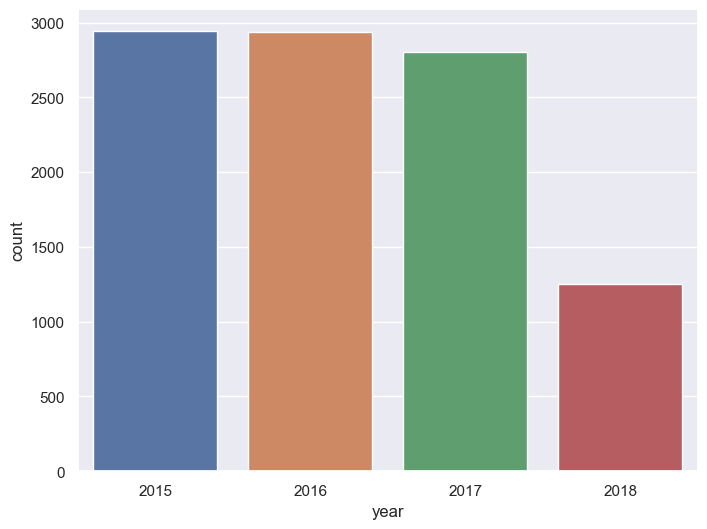

In [31]:
sns.countplot(X_train['year'])

<AxesSubplot:xlabel='year', ylabel='count'>

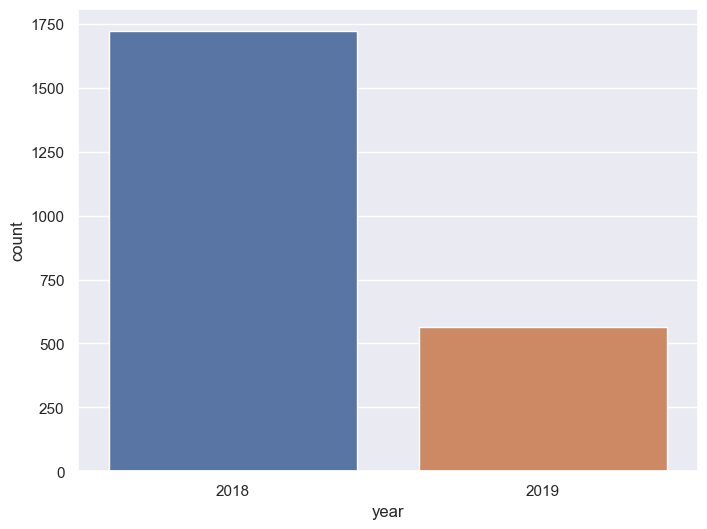

In [32]:
sns.countplot(X_test['year'])

In [33]:
X_train.head()

,best_of,p2_age,p2_hand,p2_ht,p2_id,p2_ioc,p2_rank,p2_rank_points,p2_seed,match_num,...,p1_ht,p1_id,p1_ioc,p1_rank,p1_rank_points,p1_seed,day,month,year,is_weekend
0,3,31.75,L,188.0,104269,ESP,43.0,995.0,6.0,2,...,188.0,104542,FRA,19.0,1645.0,6.0,16,8,2015,1
1,3,30.97,R,183.0,104571,CYP,41.0,1060.0,6.0,275,...,185.0,105526,GER,89.0,650.0,6.0,6,6,2016,0
2,5,26.11,L,183.0,105385,USA,68.0,730.0,6.0,117,...,183.0,104527,SUI,5.0,5710.0,5.0,31,8,2015,0
3,3,28.71,L,185.0,104745,ESP,3.0,5745.0,1.0,25,...,180.0,104655,URU,23.0,1447.0,6.0,16,2,2015,0
4,3,27.46,R,190.0,104997,NED,100.0,556.0,6.0,12,...,185.0,104433,CAN,156.0,326.0,6.0,2,2,2015,0


In [52]:
from sklearn.preprocessing import OneHotEncoder

params['low_cardinality_cols'] = ['best_of', 'p2_hand',  'p1_hand', 'round', 'surface', 'tourney_level']

OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[params['low_cardinality_cols'] ]))
OH_cols_train.columns = OH_encoder.get_feature_names_out()
print(OH_cols_train.columns)

OH_cols_test = pd.DataFrame(OH_encoder.transform(X_test[params['low_cardinality_cols'] ]))
OH_cols_test.columns = OH_encoder.get_feature_names_out()
# One-hot encoding removed index; put it back
OH_cols_train.index = X_train.index
OH_cols_test.index = X_test.index


# Remove categorical columns (will replace with one-hot encoding)
other_X_train = X_train.drop(params['low_cardinality_cols'] , axis=1)
other_X_test = X_test.drop(params['low_cardinality_cols'] , axis=1)

# Add one-hot encoded columns to numerical features
encoded_X_train = pd.concat([other_X_train, OH_cols_train], axis=1)
encoded_X_test = pd.concat([other_X_test, OH_cols_test], axis=1) 

Index(['best_of_3', 'best_of_5', 'p2_hand_L', 'p2_hand_R', 'p2_hand_U',
       'p1_hand_L', 'p1_hand_R', 'p1_hand_U', 'round_BR', 'round_F',
       'round_QF', 'round_R128', 'round_R16', 'round_R32', 'round_R64',
       'round_RR', 'round_SF', 'surface_Carpet', 'surface_Clay',
       'surface_Grass', 'surface_Hard', 'tourney_level_A', 'tourney_level_D',
       'tourney_level_F', 'tourney_level_G', 'tourney_level_M'],
      dtype='object')


In [36]:
X_train['surface'].head()

0     Hard
1    Grass
2     Hard
3     Clay
4     Hard
Name: surface, dtype: object

In [37]:
encoded_X_train[['surface_Hard','surface_Grass', 'surface_Carpet', 'surface_Clay']].head()

,surface_Hard,surface_Grass,surface_Carpet,surface_Clay
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0


In [38]:
def add_noise(series, noise_level):
    return series * (1 + noise_level * np.random.randn(len(series)))

def target_encode(trn_series=None,  
                  target=None, 
                  min_samples_leaf=1, 
                  smoothing=1):

    temp = pd.concat([trn_series, target], axis=1)
    
    # Compute target mean 
    averages = temp.groupby(by=trn_series.name)[target.name].agg(["mean", "count"])
    
    # Compute smoothing
    smoothing = 1 / (1 + np.exp(-(averages["count"] - min_samples_leaf) / smoothing))
    
    # Apply average function to all target data
    prior = target.mean()
    
    # The bigger the count the less full_avg is taken into account
    averages[target.name] = prior * (1 - smoothing) + averages["mean"] * smoothing
    averages.drop(["mean", "count"], axis=1, inplace=True)
    
    return averages, prior
    
def transform(trn_series, averages, prior, noise_level=0.01):
    # Apply averages 
    ft_trn_series = pd.merge(
        trn_series.to_frame(trn_series.name),
        averages.reset_index().rename(columns={'index': 'p1_won', 'p1_won': 'average'}),
        on=trn_series.name,
        how='left')['average'].rename(trn_series.name + '_mean').fillna(prior)

    # pd.merge does not keep the index so restore it
    ft_trn_series.index = trn_series.index 

    return  add_noise(ft_trn_series, noise_level)


In [39]:
for feature in params['categorical_features_target_encoding']:
    averages, prior = target_encode(trn_series=X_train[feature], 
                             target=y_train, 
                             min_samples_leaf=100,
                             smoothing=10)
    encoded_X_train[feature] = transform(encoded_X_train[feature], averages, prior, noise_level=0.01)
    encoded_X_test[feature] = transform(encoded_X_test[feature], averages, prior, noise_level=0.01)


In [40]:
X_train.columns

Index(['best_of', 'p2_age', 'p2_hand', 'p2_ht', 'p2_id', 'p2_ioc', 'p2_rank',
       'p2_rank_points', 'p2_seed', 'match_num', 'round', 'surface',
       'tourney_level', 'p1_age', 'p1_hand', 'p1_ht', 'p1_id', 'p1_ioc',
       'p1_rank', 'p1_rank_points', 'p1_seed', 'day', 'month', 'year',
       'is_weekend'],
      dtype='object')

In [41]:
encoded_X_train.head()

,p2_age,p2_ht,p2_id,p2_ioc,p2_rank,p2_rank_points,p2_seed,match_num,p1_age,p1_ht,...,round_SF,surface_Carpet,surface_Clay,surface_Grass,surface_Hard,tourney_level_A,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M
0,31.75,188.0,0.485303,0.446222,43.0,995.0,6.0,2,30.33,188.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,30.97,183.0,0.500034,0.490737,41.0,1060.0,6.0,275,26.12,185.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,26.11,183.0,0.493691,0.504293,68.0,730.0,6.0,117,30.43,183.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,28.71,185.0,0.226150,0.446664,3.0,5745.0,1.0,25,29.13,180.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,27.46,190.0,0.491212,0.553357,100.0,556.0,6.0,12,30.35,185.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [42]:
encoded_X_test.head()

,p2_age,p2_ht,p2_id,p2_ioc,p2_rank,p2_rank_points,p2_seed,match_num,p1_age,p1_ht,...,round_SF,surface_Carpet,surface_Clay,surface_Grass,surface_Hard,tourney_level_A,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M
0,25.77,185.0,0.483633,0.534653,215.0,257.0,6.0,271,28.29,180.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,32.36,185.0,0.473272,0.467896,28.0,1535.0,6.0,284,26.09,185.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,27.01,185.0,0.491654,0.489542,38.0,1080.0,6.0,297,29.12,178.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,28.37,178.0,0.345777,0.428436,24.0,1665.0,6.0,291,34.58,178.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,22.54,185.0,0.491606,0.574924,36.0,1182.0,6.0,175,20.04,185.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


--------------------------------------------------------------------------------------------------------------
<a id = 'train'></a>
### 4. Entrainement des modèles

In [43]:
def display_classification_result(y_true, y_pred, name_classifiers, train_time, test_time):
    """
    Display evaluation metrics 
    """

    reports = []
    metrics = ["Classifier", "Accuracy", "Precision", "Recall", "F1-Score", "Training Duration(sec)", "Prediction Duration (sec)"]

    for idx, y_clf in enumerate(y_pred):
        acc = accuracy_score(y_true, y_clf)
        pre = precision_score(y_true, y_clf)
        rec = recall_score(y_true, y_clf)
        f1s = f1_score(y_true, y_clf)
        report = (name_classifiers[idx], acc, pre, rec, f1s, train_time[idx], test_time[idx])
        reports.append(report)
            
    display(pd.DataFrame.from_records(reports, columns=metrics))

In [44]:
dic = {'DecisionTreeClassifier':DecisionTreeClassifier(),
       'RandomForestClassifier': RandomForestClassifier(), 
       'LGBMClassifier': LGBMClassifier(),
       'XGBClassifier':XGBClassifier()
       }

train_time = []

for name, clf in dic.items():
    tic = time()
    clf.fit(encoded_X_train, y_train)
    toc = time()
    train_time.append(toc - tic)
    
    print(" {} - Training duration : {} sec".format(name, train_time[-1]))

 DecisionTreeClassifier - Training duration : 0.17935800552368164 sec
 RandomForestClassifier - Training duration : 1.99928879737854 sec
 LGBMClassifier - Training duration : 0.18697905540466309 sec
 XGBClassifier - Training duration : 0.5012009143829346 sec


In [45]:
y_test_pred = []
test_time = []
for name, clf in dic.items():
    tic = time()
    y_test_pred.append(clf.predict(encoded_X_test))
    toc = time()
    test_time.append(toc - tic)

In [46]:
display_classification_result(y_test, y_test_pred, list(dic.keys()), train_time, test_time)


,Classifier,Accuracy,Precision,Recall,F1-Score,Training Duration(sec),Prediction Duration (sec)
0,DecisionTreeClassifier,0.552448,0.586431,0.521488,0.552056,0.179358,0.008002
1,RandomForestClassifier,0.633741,0.674157,0.595041,0.632133,1.999289,0.072007
2,LGBMClassifier,0.624563,0.654354,0.614876,0.634001,0.186979,0.000000
3,XGBClassifier,0.612762,0.645946,0.592562,0.618103,0.501201,0.008001


--------------------------------------------------------------------------------------------------------------
<a id = 'finetune'></a>
### 5. Fine Tuning

In [47]:
def fine_tune_best_model(X_train , y_train) :
    """ Train and finetune model  """

    print(f'''\n{'-'*20} Train LightGBM model  {'-'*20}''')
    model = LGBMClassifier
    model().fit(X_train, y_train)
    
    print(f'''\n{'-'*20} Finetune LightGBM model  {'-'*20}''')
    n_splits = 3
    tscv = TimeSeriesSplit(n_splits)
    X_train= X_train.copy()
    X_train['date'] = pd.to_datetime(X_train[['year', 'month', 'day']])
    X_train = X_train.sort_values('date')
    X_train.drop(columns=['date'], inplace=True)

    clf = GridSearchCV(
            estimator=model(),
            param_grid={'num_leaves': (15, 31, 45),
                        'max_depth': (-1, 5, 10),
                        'learning_rate': (0.05, 0.1, 0.2),
                        'n_estimators': (25, 50, 100)
                        },
            scoring='f1',
            cv=tscv,
            n_jobs=3,
            verbose=1,
            refit=True)
    
    clf.fit(X_train,y_train)
    # printing the best parameters
    print(f"Best parameters {clf.best_params_}")
    return model(**clf.best_params_)

In [48]:
model_best_hyperp = fine_tune_best_model(encoded_X_train, y_train)


-------------------- Train LightGBM model  --------------------

-------------------- Finetune LightGBM model  --------------------
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters {'learning_rate': 0.2, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}


In [49]:
start_train = time()
model_best_hyperp.fit(encoded_X_train, y_train)
end_train = time()

start_test = time()
y_test_pred = model_best_hyperp.predict(encoded_X_test)
end_test = time()
display_classification_result(y_test, [y_test_pred], ['Fine Tuned LGB'], [end_train - start_train], [end_test - start_test])


,Classifier,Accuracy,Precision,Recall,F1-Score,Training Duration(sec),Prediction Duration (sec)
0,Fine Tuned LGB,0.608829,0.639504,0.596694,0.617358,0.136014,0.008003


--------------------------------------------------------------------------------------------------------------
<a id = 'predict'></a>
### 6. Result Analysis

We will use SHAP (SHapley Additive exPlanations) library which is a game theoretic approach to explain the output of any machine learning model. It will allow as visualize the behaviour of the classifer as well as the most important features used.

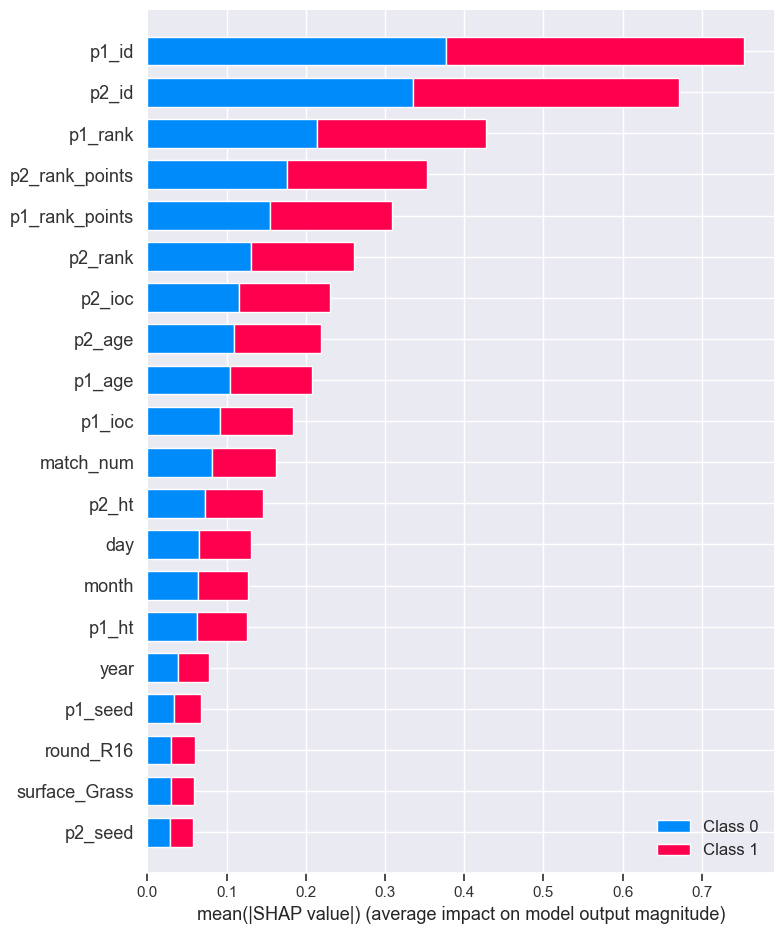

In [50]:
# explication of model results with shap values
explainer = shap.TreeExplainer(model_best_hyperp)
shap_values = explainer.shap_values(encoded_X_test)
shap.summary_plot(shap_values, encoded_X_test)


This plot allow as to get an overview of which features are most important for a model. "id", "rank" and "rank_points" are the most important features. This is expected as those features express directly the id and the level of performance of each player.

The color represents the feature value (red high, blue low). This reveals for example that a high first_rank (rank of first player) lowers the predicted labels (label tends vers 0).